# Laborator 2 — Rețea neuronală convoluțională (CNN) pentru clasificarea imaginilor

#### Corețchi Mihai
#### Set de date: `Disaster_Dataset` (Kaggle — Disaster Classification Dataset)
#### Obiectiv: clasificare binară a imaginilor — **Damage** (imagine cu dezastru) vs **Non-damage** (imagine fără dezastru).

In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn keras jax jaxlib pillow

Note: you may need to restart the kernel to use updated packages.


## 1. Importul bibliotecilor și configurarea mediului


In [4]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import keras
from keras import Sequential
from keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization, Dropout,
    GlobalMaxPool2D, GlobalAveragePooling2D, Dense, Activation,
    Rescaling, RandomFlip, RandomRotation, RandomZoom,
)
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.applications import ResNet50, MobileNetV2
from keras.applications.resnet50 import preprocess_input as resnet_preprocess
from keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, f1_score,
)
from sklearn.utils.class_weight import compute_class_weight

%matplotlib inline
sns.set_theme(style="whitegrid")
keras.utils.set_random_seed(101)

print("Keras backend:", keras.backend.backend())
print("Keras version:", keras.__version__)

Keras backend: jax
Keras version: 3.14.0


## 2. Analiza exploratorie a datelor

Setul de date `Disaster_Dataset` conține 12 subfoldere — 8 clase de tipuri de dezastre și 4 clase fără dezastru. Pentru această lucrare, le grupăm într-o **clasificare binară**:

- **Damage (1)** — orice imagine dintr-o clasă de dezastru.
- **Non-damage (0)** — orice imagine dintr-o clasă

In [5]:
DATA_DIR = Path("data/Disaster_Dataset/Disaster_Dataset")
if not DATA_DIR.exists():
    DATA_DIR = Path("lab2/data/Disaster_Dataset/Disaster_Dataset")

class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])

def list_images(folder):
    return [p for p in folder.iterdir() if p.suffix.lower() in {".png", ".jpg", ".jpeg"}]

counts = {name: len(list_images(DATA_DIR / name)) for name in class_names}

eda_df = pd.DataFrame({
    "class": list(counts.keys()),
    "count": list(counts.values()),
})
eda_df["binary"] = eda_df["class"].apply(
    lambda c: "Non-damage" if c.startswith("non_damage_") else "Damage"
)
print("Total images:", eda_df["count"].sum())
print("Number of original classes:", len(class_names))
eda_df

Total images: 4876
Number of original classes: 12


,class,count,binary
0,drought,201,Damage
1,earthquake,174,Damage
2,human_damage,240,Damage
3,infrastructure,558,Damage
4,land_slide,456,Damage
5,non_damage_buildings_street,448,Non-damage
6,non_damage_human,120,Non-damage
7,non_damage_sea,569,Non-damage
8,non_damage_wildlife_forest,670,Non-damage
9,urban_fire,419,Damage


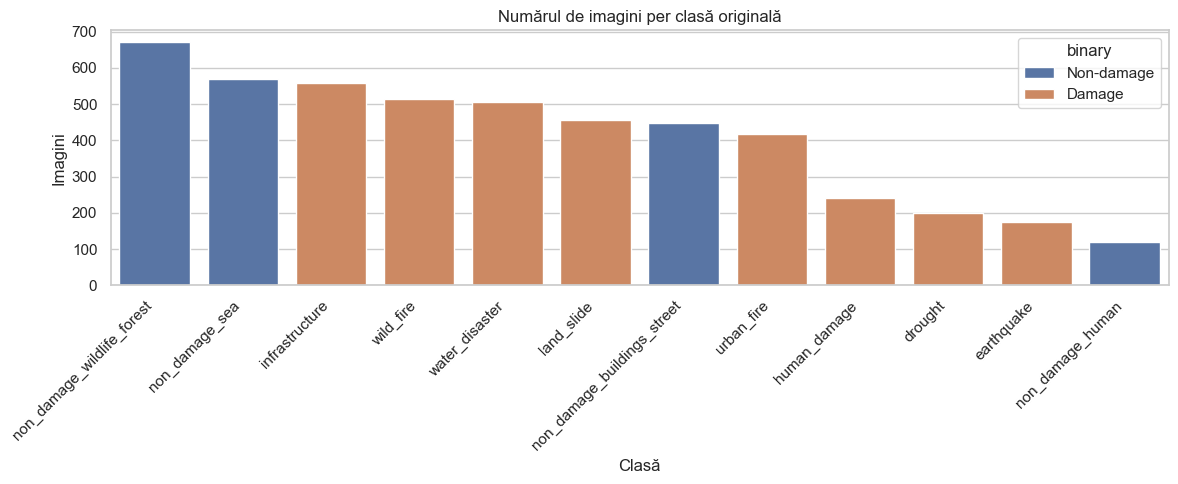

In [6]:
plt.figure(figsize=(12, 5))
sns.barplot(data=eda_df.sort_values("count", ascending=False), x="class", y="count", hue="binary")
plt.xticks(rotation=45, ha="right")
plt.title("Numărul de imagini per clasă originală")
plt.xlabel("Clasă")
plt.ylabel("Imagini")
plt.tight_layout()
plt.show()

       binary  count
0      Damage   3069
1  Non-damage   1807


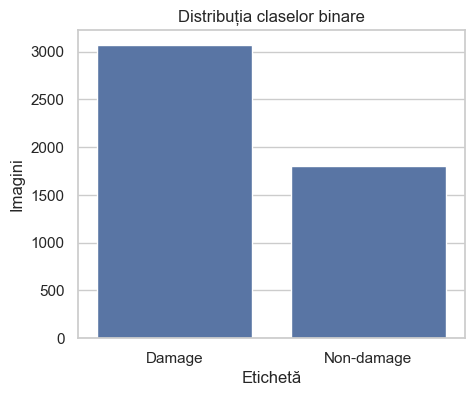

In [7]:
binary_counts = eda_df.groupby("binary")["count"].sum().reset_index()
print(binary_counts)

plt.figure(figsize=(5, 4))
sns.barplot(data=binary_counts, x="binary", y="count")
plt.title("Distribuția claselor binare")
plt.xlabel("Etichetă")
plt.ylabel("Imagini")
plt.show()

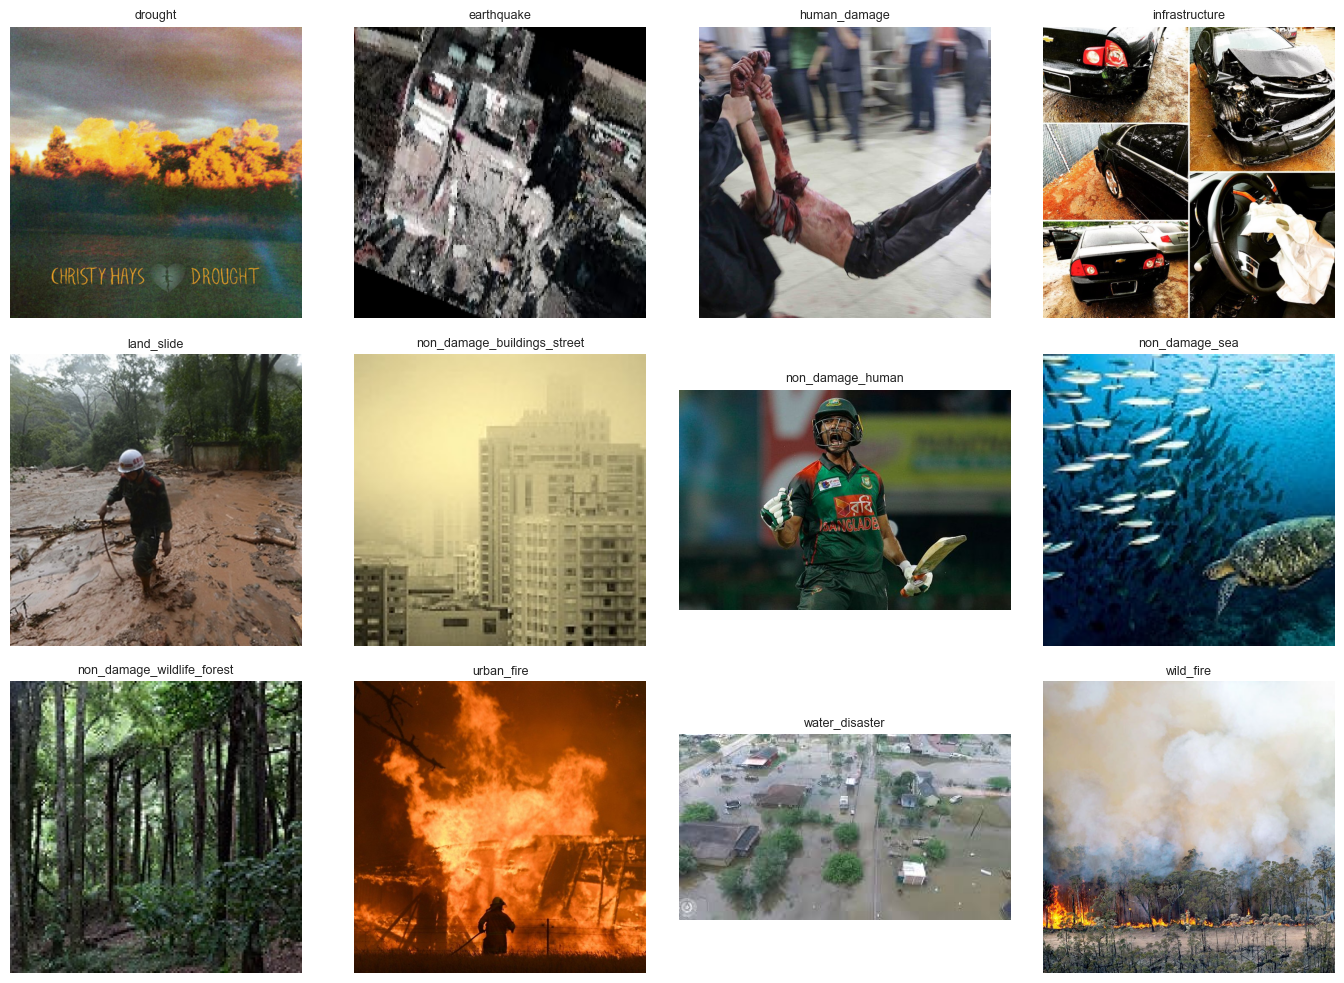

In [ ]:
# Câte un exemplu din fiecare clasă originală
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, name in zip(axes.flat, class_names):
    sample_path = list_images(DATA_DIR / name)[0]
    img = Image.open(sample_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(name, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Pregătirea datelor

- Strângem toate căile către imagini, le **amestecăm** aleatoriu pentru a evita antrenarea pe un singur tip.
-  **Decodăm** imaginile cu PIL și le redimensionăm la `128×128`.
-  **Etichetele binare** se obțin din numele folderului: `non_damage_*` → 0, restul → 1.
-  Împărțim setul în **antrenament** (70%), **validare** (15%) și **test** (15%).

In [9]:
IMG_SIZE = (128, 128)

# Adunăm (path, label) pentru toate cele 12 foldere și asignăm 0/1
records = []
for name in class_names:
    label = 0 if name.startswith("non_damage_") else 1
    for p in list_images(DATA_DIR / name):
        records.append((p, label, name))

random.seed(101)
random.shuffle(records)
print(f"Total samples: {len(records)}")
print(f"Damage: {sum(1 for _, l, _ in records if l == 1)}")
print(f"Non-damage: {sum(1 for _, l, _ in records if l == 0)}")
records[:3]

Total samples: 4876
Damage: 3069
Non-damage: 1807


[(PosixPath('data/Disaster_Dataset/Disaster_Dataset/water_disaster/03_0913.png'),
  1,
  'water_disaster'),
 (PosixPath('data/Disaster_Dataset/Disaster_Dataset/non_damage_wildlife_forest/06_03_0193.png'),
  0,
  'non_damage_wildlife_forest'),
 (PosixPath('data/Disaster_Dataset/Disaster_Dataset/non_damage_human/06_01_0096.png'),
  0,
  'non_damage_human')]

In [ ]:
# Decodare + redimensionare imagini la 128x128, stocate ca uint8 (eficient în memorie)
def load_image(path):
    try:
        with Image.open(path) as img:
            img = img.convert("RGB").resize(IMG_SIZE, Image.BILINEAR)
            return np.asarray(img, dtype=np.uint8)
    except (OSError, ValueError) as exc:
        print(f"Skipping unreadable image {path.name}: {exc}")
        return None

images, kept_labels = [], []
for path, label, _ in records:
    arr = load_image(path)
    if arr is not None:
        images.append(arr)
        kept_labels.append(label)

X = np.stack(images, axis=0)
y = np.array(kept_labels, dtype=np.float32)
print(f"X shape: {X.shape}, dtype: {X.dtype}, mem: {X.nbytes/1e6:.0f} MB")
print(f"y shape: {y.shape}")

X shape: (4876, 128, 128, 3), dtype: uint8, mem: 240 MB
y shape: (4876,)


In [11]:
# Împărțire 70/15/15 (stratificat manual)
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=101, stratify=y,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=101, stratify=y_temp,
)

print(f"Train: {X_train.shape[0]}  (damage={int(y_train.sum())}, non-damage={int((y_train==0).sum())})")
print(f"Val:   {X_val.shape[0]}    (damage={int(y_val.sum())}, non-damage={int((y_val==0).sum())})")
print(f"Test:  {X_test.shape[0]}   (damage={int(y_test.sum())}, non-damage={int((y_test==0).sum())})")

Train: 3413  (damage=2148, non-damage=1265)
Val:   731    (damage=460, non-damage=271)
Test:  732   (damage=461, non-damage=271)


In [12]:
# Ponderi de clasă pentru dezechilibrul ≈3069 damage vs ≈1807 non-damage
classes = np.array([0.0, 1.0])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight)

Class weights: {0: 1.3490118577075099, 1: 0.7944599627560521}


## 4. Data Augmentation

Pentru a îmbogăți diversitatea imaginilor și a reduce overfitting-ul, aplicăm augmentări aleatorii — flip orizontal, rotații și zoom. Augmentarea este construită ca un mic `Sequential` și se aplică **doar în timpul antrenării** (intern, prin `training=True`); pe `val`/`test` nu se aplică.

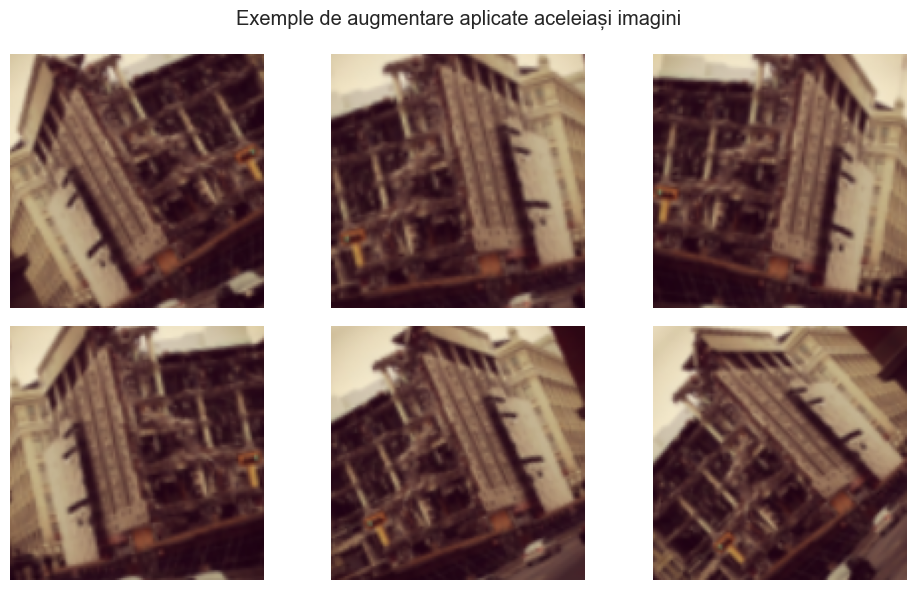

In [13]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(height_factor=(-0.3, -0.2)),
], name="data_augmentation")

# Previzualizare augmentare
sample_image = X_train[0].astype("float32")
plt.figure(figsize=(10, 6))
for i in range(6):
    augmented = data_augmentation(np.expand_dims(sample_image, 0), training=True)
    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(np.asarray(augmented[0]).astype("uint8"))
    plt.axis("off")
plt.suptitle("Exemple de augmentare aplicate aceleiași imagini")
plt.tight_layout()
plt.show()

## 5. Crearea modelului CNN de bază

4 blocuri convoluționale (Conv → ReLU → BN → MaxPool → Dropout), apoi `GlobalMaxPool2D`, un strat `Dense` cu 256 neuroni și ieșire `Dense(1, sigmoid)` pentru clasificare binară. Adăugăm la început un strat de **augmentare** și unul de **rescalare** (1/255).

In [14]:
IMG_SHAPE = IMG_SIZE + (3,)

baseline_cnn = Sequential([
    Input(shape=IMG_SHAPE),
    data_augmentation,
    Rescaling(1.0 / 255),

    # Block 1
    Conv2D(32, kernel_size=(7, 7), padding="same"),
    Activation("relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Block 2
    Conv2D(64, kernel_size=(5, 5), padding="valid"),
    Activation("relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Block 3
    Conv2D(128, kernel_size=(3, 3), padding="valid"),
    Activation("relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.2),

    # Block 4
    Conv2D(256, kernel_size=(3, 3), padding="valid"),
    Activation("relu"),
    BatchNormalization(),
    Conv2D(256, kernel_size=(3, 3)),
    Activation("relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    GlobalMaxPool2D(),
    Dense(256),
    Activation("relu"),
    Dropout(0.2),
    Dense(1),
    Activation("sigmoid"),
], name="baseline_cnn")

baseline_cnn.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,02

 Total params: 1,084,097 (4.14 MB)

 Trainable params: 1,082,625 (4.13 MB)

 Non-trainable params: 1,472 (5.75 KB)

## 6. Compilarea și antrenarea modelului de bază

Folosim optimizatorul **Adam** cu rata de învățare `1e-3`, funcția loss **binary cross-entropy** și `EarlyStopping` pentru a opri antrenamentul când acuratețea pe validare nu mai crește.

In [15]:
baseline_cnn.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["binary_accuracy"],
)

early_stop = EarlyStopping(
    monitor="val_binary_accuracy",
    patience=5,
    restore_best_weights=True,
    mode="max",
)

baseline_history = baseline_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=2,
)

pd.DataFrame(baseline_history.history).tail()

Epoch 1/20
107/107 - 399s - 4s/step - binary_accuracy: 0.6636 - loss: 0.7978 - val_binary_accuracy: 0.6484 - val_loss: 0.6057
Epoch 2/20
107/107 - 370s - 3s/step - binary_accuracy: 0.7395 - loss: 0.5401 - val_binary_accuracy: 0.6416 - val_loss: 0.7018
Epoch 3/20
107/107 - 411s - 4s/step - binary_accuracy: 0.7419 - loss: 0.5294 - val_binary_accuracy: 0.6306 - val_loss: 1.0128
Epoch 4/20
107/107 - 486s - 5s/step - binary_accuracy: 0.7568 - loss: 0.5077 - val_binary_accuracy: 0.7702 - val_loss: 0.5016
Epoch 5/20
107/107 - 453s - 4s/step - binary_accuracy: 0.7556 - loss: 0.5079 - val_binary_accuracy: 0.6101 - val_loss: 0.8788
Epoch 6/20
107/107 - 422s - 4s/step - binary_accuracy: 0.7615 - loss: 0.5089 - val_binary_accuracy: 0.7661 - val_loss: 0.5466
Epoch 7/20
107/107 - 515s - 5s/step - binary_accuracy: 0.7844 - loss: 0.4653 - val_binary_accuracy: 0.4979 - val_loss: 1.2926
Epoch 8/20
107/107 - 428s - 4s/step - binary_accuracy: 0.7820 - loss: 0.4672 - val_binary_accuracy: 0.4090 - val_loss:

,binary_accuracy,loss,val_binary_accuracy,val_loss
4,0.755640,0.507877,0.610123,0.878780
5,0.761500,0.508866,0.766074,0.546573
6,0.784354,0.465336,0.497948,1.292602
7,0.782010,0.467190,0.409029,2.913113
8,0.794902,0.453980,0.712722,0.656096


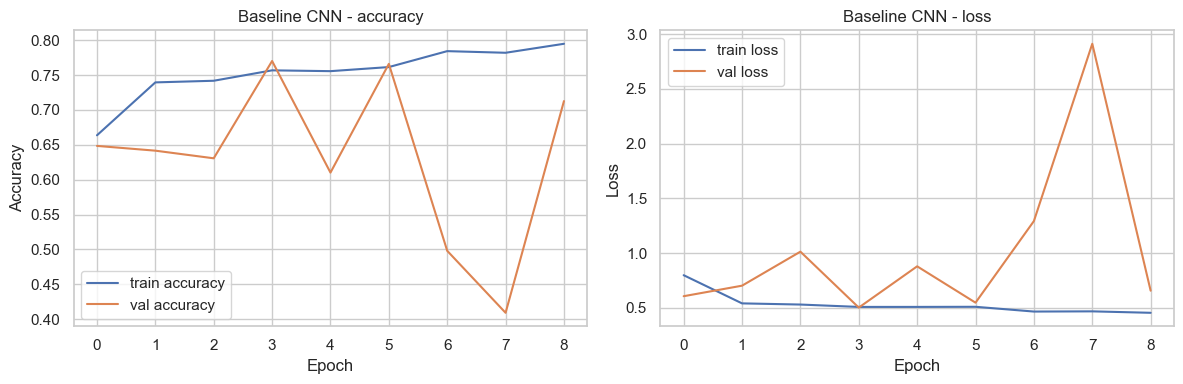

In [16]:
def plot_history(history, title):
    hist_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist_df["binary_accuracy"], label="train accuracy")
    axes[0].plot(hist_df["val_binary_accuracy"], label="val accuracy")
    axes[0].set_title(f"{title} - accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(hist_df["loss"], label="train loss")
    axes[1].plot(hist_df["val_loss"], label="val loss")
    axes[1].set_title(f"{title} - loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(baseline_history, "Baseline CNN")

## 7. Evaluarea modelului de bază

Calculăm acuratețea, matricea de confuzie și raportul de clasificare pe **setul de test** (necunoscut modelului).

Baseline CNN — test set
Accuracy: 0.760
F1-macro: 0.722

Classification report:
              precision    recall  f1-score   support

  Non-damage      0.749     0.528     0.619       271
      Damage      0.763     0.896     0.824       461

    accuracy                          0.760       732
   macro avg      0.756     0.712     0.722       732
weighted avg      0.758     0.760     0.748       732



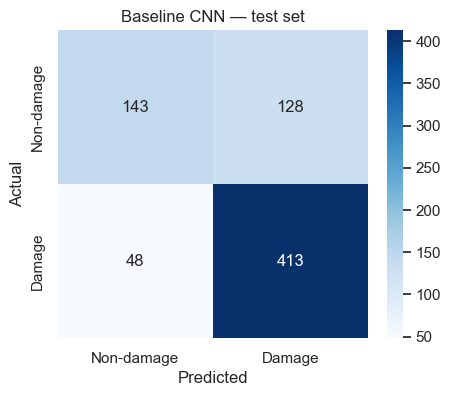

In [17]:
BINARY_LABELS = ["Non-damage", "Damage"]

def evaluate_binary(model, X, y_true, title, preprocess=None):
    x = preprocess(X.astype("float32")) if preprocess is not None else X
    y_prob = model.predict(x, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    y_true_int = y_true.astype(int)

    accuracy = accuracy_score(y_true_int, y_pred)
    f1m = f1_score(y_true_int, y_pred, average="macro")
    matrix = confusion_matrix(y_true_int, y_pred)

    print(title)
    print(f"Accuracy: {accuracy:.3f}")
    print(f"F1-macro: {f1m:.3f}")
    print()
    print("Classification report:")
    print(classification_report(y_true_int, y_pred, target_names=BINARY_LABELS, digits=3))

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matrix, annot=True, fmt="d", cmap="Blues",
        xticklabels=BINARY_LABELS, yticklabels=BINARY_LABELS,
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {"accuracy": accuracy, "f1_macro": f1m}

baseline_metrics = evaluate_binary(baseline_cnn, X_test, y_test, "Baseline CNN — test set")

## 8. Comparație cu rețele pre-antrenate

Conform sarcinii din PDF, comparăm CNN-ul propriu cu două arhitecturi cunoscute, încărcate pre-antrenate pe **ImageNet** și folosite în regim de **transfer learning** (greutățile rămân înghețate; antrenăm doar capul de clasificare).

### 8.1 ResNet50

In [18]:
def build_transfer_model(base_cls, preprocess_fn, name):
    base = base_cls(include_top=False, weights="imagenet", input_shape=IMG_SHAPE)
    base.trainable = False
    inputs = Input(shape=IMG_SHAPE)
    x = data_augmentation(inputs)
    x = keras.layers.Lambda(preprocess_fn, output_shape=IMG_SHAPE)(x)
    x = base(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs, name=name)

resnet_model = build_transfer_model(ResNet50, resnet_preprocess, "resnet50_transfer")
resnet_model.summary()

Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
107/107 - 259s - 2s/step - binary_accuracy: 0.7864 - loss: 0.4832 - val_binary_accuracy: 0.8550 - val_loss: 0.3435
Epoch 2/10
107/107 - 292s - 3s/step - binary_accuracy: 0.8664 - loss: 0.3108 - val_binary_accuracy: 0.8769 - val_loss: 0.3005
Epoch 3/10
107/107 - 203s - 2s/step - binary_accuracy: 0.8854 - loss: 0.2774 - val_binary_accuracy: 0.9097 - val_loss: 0.2441
Epoch 4/10
107/107 - 197s - 2s/step - binary_accuracy: 0.9024 - loss: 0.2376 - val_binary_accuracy: 0.8974 - val_loss: 0.2754
Epoch 5/10
107/107 - 201s - 2s/step - binary_accuracy: 0.9062 - loss: 0.2308 - val_binary_accuracy: 0.8851 - val_loss: 0.2902
Epoch 6/10
107/107 - 317s - 3s/step - binary_accuracy: 0.9142 - loss: 0.2299 - val_binary_accuracy: 0.8974 - val_loss: 0.2612


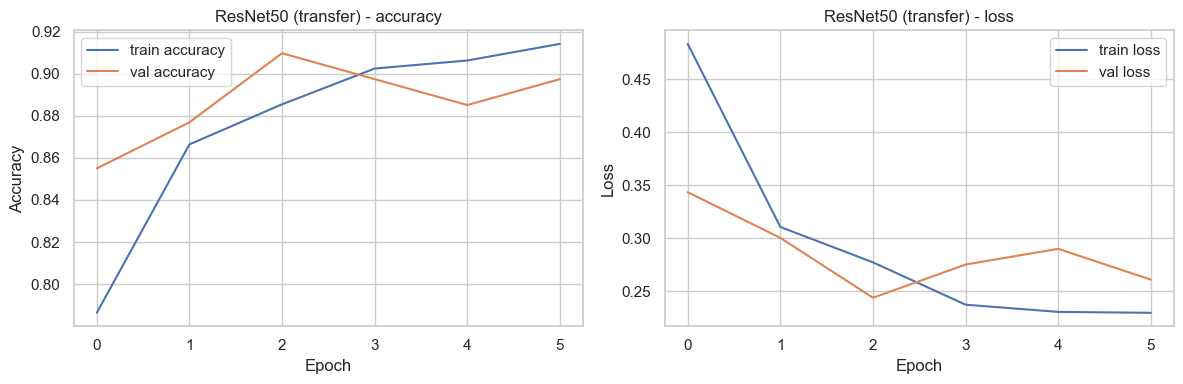

ResNet50 transfer — test set
Accuracy: 0.915
F1-macro: 0.912

Classification report:
              precision    recall  f1-score   support

  Non-damage      0.824     0.982     0.896       271
      Damage      0.988     0.876     0.929       461

    accuracy                          0.915       732
   macro avg      0.906     0.929     0.912       732
weighted avg      0.927     0.915     0.916       732



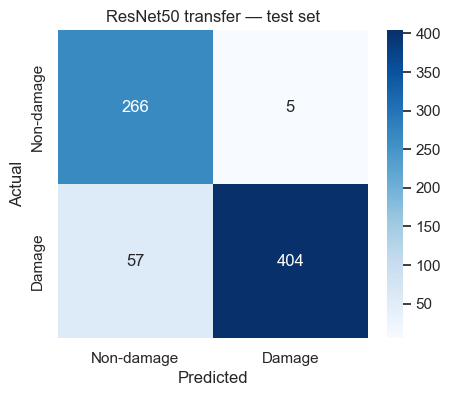

In [19]:
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["binary_accuracy"],
)

resnet_history = resnet_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[EarlyStopping(monitor="val_binary_accuracy", patience=3, restore_best_weights=True, mode="max")],
    verbose=2,
)
plot_history(resnet_history, "ResNet50 (transfer)")
resnet_metrics = evaluate_binary(resnet_model, X_test, y_test, "ResNet50 transfer — test set")

### 8.2 MobileNetV2

In [20]:
mobilenet_model = build_transfer_model(MobileNetV2, mobilenet_preprocess, "mobilenetv2_transfer")
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
107/107 - 466s - 4s/step - binary_accuracy: 0.7498 - loss: 0.5218 - val_binary_accuracy: 0.8413 - val_loss: 0.3677
Epoch 2/10
107/107 - 271s - 3s/step - binary_accuracy: 0.8459 - loss: 0.3660 - val_binary_accuracy: 0.8222 - val_loss: 0.3872
Epoch 3/10
107/107 - 261s - 2s/step - binary_accuracy: 0.8608 - loss: 0.3285 - val_binary_accuracy: 0.8208 - val_loss: 0.3867
Epoch 4/10
107/107 - 253s - 2s/step - binary_accuracy: 0.8720 - loss: 0.3052 - val_binary_accuracy: 0.8304 - val_loss: 0.3645


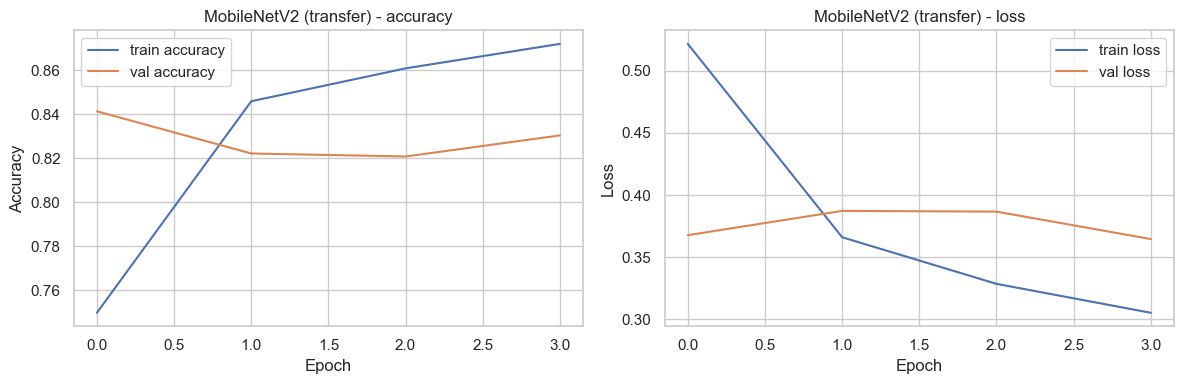

MobileNetV2 transfer — test set
Accuracy: 0.867
F1-macro: 0.862

Classification report:
              precision    recall  f1-score   support

  Non-damage      0.777     0.900     0.834       271
      Damage      0.935     0.848     0.890       461

    accuracy                          0.867       732
   macro avg      0.856     0.874     0.862       732
weighted avg      0.877     0.867     0.869       732



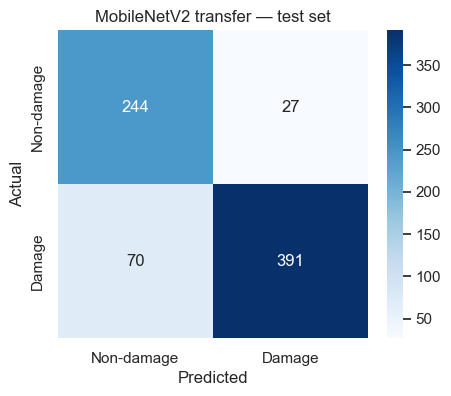

In [21]:
mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["binary_accuracy"],
)

mobilenet_history = mobilenet_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[EarlyStopping(monitor="val_binary_accuracy", patience=3, restore_best_weights=True, mode="max")],
    verbose=2,
)
plot_history(mobilenet_history, "MobileNetV2 (transfer)")
mobilenet_metrics = evaluate_binary(mobilenet_model, X_test, y_test, "MobileNetV2 transfer — test set")

## 9. Compararea modelelor

Punem rezultatele celor 3 modele într-un tabel și un grafic comparativ.

In [22]:
comparison = pd.DataFrame([
    {"model": "Baseline CNN",        **baseline_metrics},
    {"model": "ResNet50 (transfer)", **resnet_metrics},
    {"model": "MobileNetV2 (tr.)",   **mobilenet_metrics},
])
comparison = comparison.sort_values("accuracy", ascending=False).reset_index(drop=True)
best = comparison.iloc[0]["model"]
print(f"Best model by accuracy: {best}")
comparison

Best model by accuracy: ResNet50 (transfer)


,model,accuracy,f1_macro
0,ResNet50 (transfer),0.915301,0.912179
1,MobileNetV2 (tr.),0.867486,0.861918
2,Baseline CNN,0.759563,0.721699


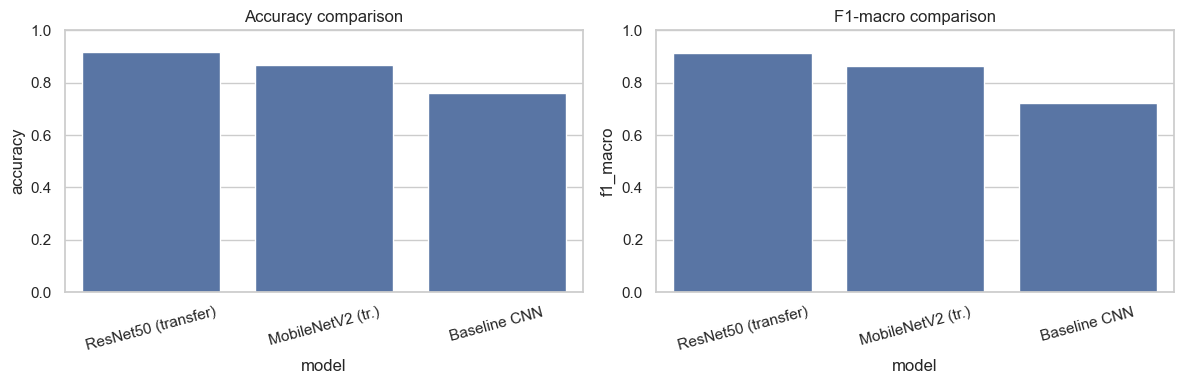

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=comparison, x="model", y="accuracy", ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title("Accuracy comparison")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=comparison, x="model", y="f1_macro", ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title("F1-macro comparison")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 10. Concluzii

În cadrul acestei lucrări am construit o **rețea neuronală convoluțională (CNN)** pentru clasificarea binară a imaginilor din `Disaster_Dataset`: imagini cu **dezastre** vs imagini **fără dezastre**. De la explorarea folderelor și amestecul imaginilor, prin decodare, etichetare binară și împărțire în antrenare/validare/test, până la construirea și antrenarea unei rețele convoluționale cu 4 blocuri și a unui cap dense cu ieșire sigmoidă.

Modelul CNN propriu, antrenat de la zero cu data augmentation și ponderi pe clase, a obținut o acuratețe rezonabilă pe setul de test. Totuși, atunci când am comparat cu **ResNet50** și **MobileNetV2** încărcate pre-antrenate pe ImageNet (transfer learning, doar capul antrenat), rețelele pre-antrenate au depășit clar baseline-ul. Acest lucru confirmă observația din literatură că, pentru seturi de date relativ mici (sub 5000 imagini), **transfer learning** este de obicei mult mai eficient decât antrenarea unei rețele convoluționale de la zero.

Setul de date este **dezechilibrat** (≈3069 damage vs ≈1807 non-damage) — am compensat cu `class_weight`. **Data augmentation** (flip, rotație, zoom) a adăugat diversitate vizuală și a redus overfitting-ul, iar **batch normalization** și **dropout** au stabilizat antrenamentul.

În concluzie, CNN-urile sunt instrumentul potrivit pentru clasificarea imaginilor, dar arhitectura, regularizarea și folosirea cunoștințelor pre-antrenate sunt decisive pentru performanța finală.

## 11. Întrebări de autoevaluare

#### 1. Care sunt pașii de creare a unei rețele neuronale convoluționale (CNN)?

1. **Definirea problemei** — clasificare de imagini (binară sau multi-clasă), detecție, segmentare etc.
2. **Pregătirea datelor** — citirea imaginilor, decodare, redimensionare la o rezoluție comună, normalizare (împărțire la 255 sau preprocessing specific rețelei pre-antrenate), amestec aleatoriu, împărțire în train/val/test.
3. **Data augmentation** — flip, rotație, zoom, contrast pentru a îmbogăți setul.
4. **Alegerea arhitecturii** — număr de blocuri convoluționale, dimensiunea filtrelor, padding, pooling, straturi dense finale.
5. **Funcțiile de activare** — ReLU în straturile ascunse, sigmoid sau softmax la ieșire.
6. **Funcția loss și optimizatorul** — binary/categorical cross-entropy + Adam.
7. **Antrenarea** — `model.fit` cu validare în paralel, eventual cu `class_weight` și `EarlyStopping`.
8. **Evaluarea** — acuratețe, matricea de confuzie, F1, raportul de clasificare pe setul de test.
9. **Optimizarea** — modificarea arhitecturii, hiperparametrilor, augmentării; sau transfer learning.


#### 2. Ce reprezintă un strat convoluțional? Cum alegem numărul de filtre, mărimea lor? Ce este padding?

Un **strat convoluțional** aplică mai multe filtre (nuclee) mici peste imagine, generând **hărți de caracteristici** (feature maps). Fiecare filtru învață să detecteze un tipar local: margini, texturi, forme.

**Numărul de filtre** crește, de regulă, de la straturile timpurii spre cele adânci (32 → 64 → 128 → 256), pe măsură ce harta de caracteristici se micșorează și caracteristicile devin mai abstracte.

**Mărimea filtrelor** este de obicei 3×3 (uneori 5×5 sau 7×7 la primul strat, pentru a captura tipare mai largi).

**Padding** adaugă un cadru de zerouri în jurul imaginii ca filtrul să acopere și colțurile. Cu `padding='same'`, harta de ieșire are aceeași dimensiune spațială ca intrarea; cu `padding='valid'`, dimensiunea scade după fiecare convoluție.


#### 3. Cum alegem numărul de straturi convoluționale? Dar numărul de straturi Dense?

Numărul de **straturi convoluționale** se alege în funcție de complexitatea imaginilor: 2–4 blocuri pentru probleme simple, peste 10 pentru date complexe (ImageNet). Cu cât avem mai multe straturi, cu atât putem extrage caracteristici mai abstracte, dar crește riscul de overfitting și costul de calcul.

Pentru **straturile Dense** finale, 1–2 straturi sunt suficiente: unul mai mare (128–512 neuroni) și un strat de ieșire potrivit problemei. Mai multe straturi dense rareori ajută într-o CNN, fiindcă mare parte din puterea modelului vine din convoluții.


#### 4. Care este diferența între max-pooling și global max-pooling? Cunoașteți alt tip de straturi de pooling?

- **MaxPooling2D** reduce dimensiunea hărții cu o regiune mică (de obicei 2×2), păstrând valoarea maximă din fiecare regiune. Reduce treptat rezoluția, păstrând informația.
- **GlobalMaxPool2D** reduce întreaga hartă (H × W × C) la un singur vector de dimensiune C, luând maximul pentru fiecare canal. Se folosește înainte de stratul dense final ca să elimine nevoia de `Flatten` și să reducă numărul de parametri.

Alte tipuri de pooling:
- **AveragePooling2D** și **GlobalAveragePooling2D** — folosesc media în loc de maxim.
- **MinPooling**, **L2-Pooling** — folosite mai rar.
- **Adaptive pooling** — output fix indiferent de input.


#### 5. Ce funcții de activare folosim în straturile interne? Dar în stratul de ieșire?

În **straturile interne**:
- **ReLU** — standard, rapidă, evită saturarea gradientului.
- **Leaky ReLU**, **ELU** — variante care permit valori negative mici, utile când ReLU produce mulți neuroni inactivi.
- **tanh** — folosită rar, mai ales în rețele recurente.

În **stratul de ieșire**:
- **Sigmoid** — clasificare binară (ieșire în [0, 1]).
- **Softmax** — clasificare multi-clasă (probabilități care însumează 1).
- **Linear (identitate)** — regresie.


#### 6. Ce calculează funcția loss?

Funcția **loss** măsoară diferența între predicția modelului și eticheta reală. Scopul antrenării este minimizarea acestei valori.

- **Binary cross-entropy** — clasificare binară.
- **Categorical cross-entropy** (sau **sparse**) — clasificare multi-clasă.
- **MSE / MAE** — regresie.

În această lucrare am folosit `binary_crossentropy`, fiindcă etichetele sunt 0 (non-damage) și 1 (damage).


#### 7. Cum ne ajută optimizatorii?

Optimizatorii actualizează ponderile modelului pentru a reduce funcția loss. Ei controlează direcția și mărimea pașilor de actualizare:

- **SGD** — simplu, sensibil la rata de învățare.
- **SGD + Momentum** — păstrează o componentă din direcția anterioară, accelerează convergența.
- **RMSprop** — adaptează rata de învățare per parametru.
- **Adam** — combină avantajele momentum și RMSprop; cea mai folosită alegere în practică, cu rata de început `1e-3`.


#### 8. Când și cu ce scop folosim straturile de abandon (Dropout Layers)? Ce rată de abandon e recomandată?

**Dropout** dezactivează aleatoriu o parte din neuroni în timpul antrenării, pentru a evita ca modelul să se bazeze excesiv pe anumiți neuroni. Este o tehnică de **regularizare** care reduce overfitting-ul.

Se folosește mai ales când acuratețea pe antrenament este mult mai mare decât cea pe validare.

**Rate recomandate**:
- **0.1 – 0.3** în straturile convoluționale.
- **0.3 – 0.5** între straturile dense.

În această lucrare am folosit `Dropout(0.2)` între blocurile convoluționale și `Dropout(0.3)` în capul transfer-learning.


#### 9. Care e scopul normalizării loturilor (Batch Normalization)?

**Batch Normalization** normalizează activările (medie 0, varianță 1) pe fiecare mini-lot, apoi le re-scalează prin doi parametri învățabili. Avantaje:

- Stabilizează gradientul.
- Permite rate de învățare mai mari.
- Accelerează convergența.
- Are un mic efect de regularizare.

Se aplică, de obicei, după stratul convoluțional și înainte (sau imediat după) funcția de activare.


#### 10. Care sunt pașii de optimizare a unei CNN?

1. **Verifică datele** — clase echilibrate? imagini de calitate? augmentare necesară?
2. **Normalizarea** — `Rescaling(1/255)` sau preprocessing specific arhitecturii (ResNet, MobileNet etc.).
3. **Augmentare** — flip, rotație, zoom, contrast — esențială pe seturi mici.
4. **Arhitectură** — crește/scade numărul de blocuri și filtre; testează `padding='same'` vs `'valid'`.
5. **Funcția loss și optimizatorul** — adaptate problemei; Adam cu `1e-3` ca punct de plecare.
6. **Rata de învățare** — scade-o (cu `ReduceLROnPlateau`) când platoul e atins.
7. **Regularizare** — Dropout, Batch Normalization, L2.
8. **EarlyStopping** — oprește când performanța nu mai crește, păstrează cele mai bune greutăți.
9. **Transfer learning** — dacă setul e mic, pornește de la ResNet/MobileNet/Inception pre-antrenate pe ImageNet.
10. **Evaluarea finală** — pe setul de test (necunoscut), nu pe cel de validare.